In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use("ggplot")

Q1. What are NSE and Nifty 50 Index? What is the index methodology? (explain  basics of share market)

The National Stock Exchange (NSE) is India’s premier financial market infrastructure. It
functions as a fully automated electronic limit order book (ELOB), matching buyers and sellers
anonymously to ensure transparency. As of late 2025, the NSE retains its status as the world's
largest derivatives exchange by volume and ranks among the top globally in cash equity trades.
The Nifty 50 Index is the flagship benchmark. It is a statistical barometer designed to reflect the
health of the Indian economy, comprising 50 of the largest and most liquid companies listed on
the exchange across 13 sectors

The Nifty 50 utilizes the Free-Float Market Capitalization Weighted method.
● Full Market Cap: Total value of all shares (Price * TotalShares).

● Free-Float Market Cap: Value of shares actually available for public
trading (Price * Total Shares * Investible Weight Factor).

● Investible Weight Factor (IWF): A unit between 0 and 1 indicating the percentage of non-
promoter holding.
Why this matters: This prevents companies with large promoter holdings (low liquidity) from
skewing the index.

● Example: Reliance Industries often has a higher total market cap than HDFC Bank.
However, because HDFC Bank has a higher IWF (nearly 1.0) compared to Reliance
(approx. 0.50), HDFC Bank often commands a higher weight in the index
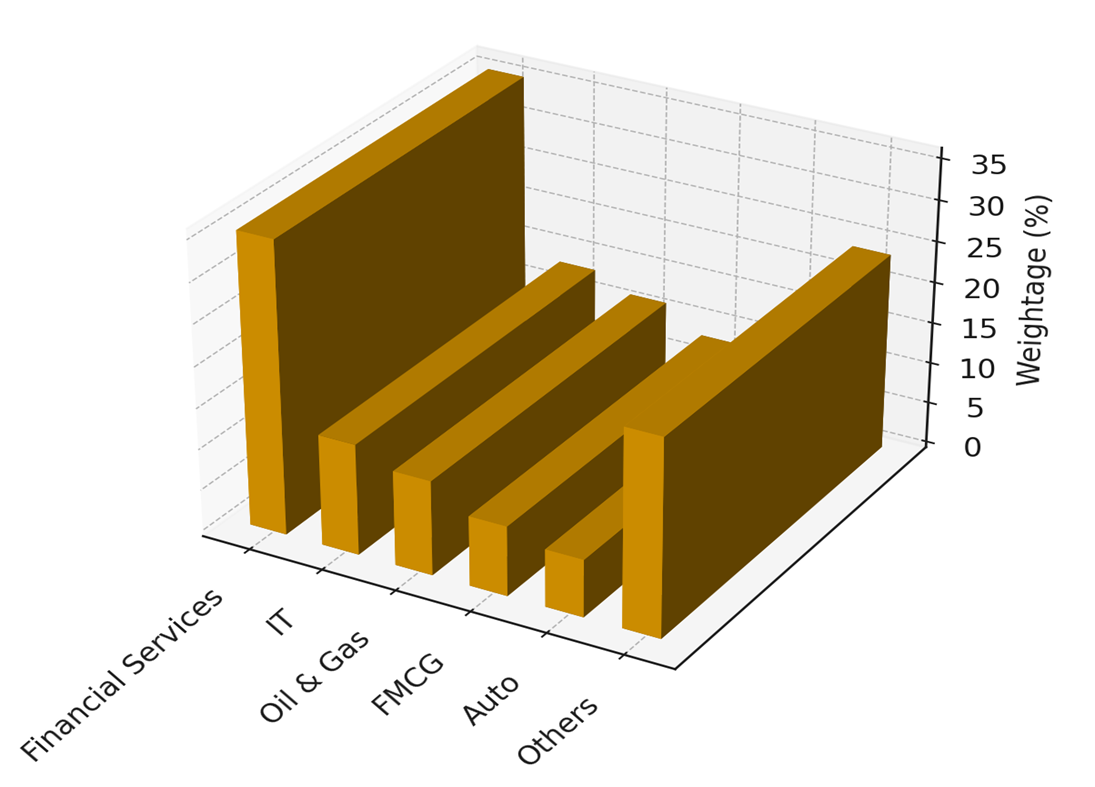

Q2.Why do we need to invest? Does it increase my stress level? Why shouldn’t I deposit my money
in a reputed bank, and get the nominal interest without any worry?

The necessity of investing stems from the Real Rate of Return (Rreal) calculation:

**𝑅𝑟𝑒𝑎𝑙 ≈ 𝑅𝑛𝑜𝑚𝑖𝑎𝑙 − 𝐼𝑛𝑓𝑙𝑎𝑡𝑖𝑜𝑛(𝜋)**

While bank Fixed Deposits (FDs) offer capital safety, they fail to protect wealth against inflation
in the long run.
● Current Context: While October 2025 saw a rare inflation dip to 0.25% due to base
effects, the long-term structural inflation average in India is ~6%.
● The Calculation: An SBI FD offering 6.60% taxed at the 30% slab yields a net 4.62%. If
inflation is 6%, the real return is negative (-1.38%)

Investing introduces volatility (price fluctuation), which causes short-term stress. However,
volatility is not a risk (permanent loss).
● Mitigation: Historical data (2015-2025) shows that the probability of negative returns in the
Nifty 50 drops to near zero for holding periods exceeding 7 years.
● Psychology: Stress arises from checking prices daily. Investors must shift focus from
"Daily Price" to "Long-term Value."


Q3. How can one be an effective investor (based on historical data and associated information)?
Shall I invest some amount daily, or in a particular day of a month, or once in a month? Is the
stock market operational daily, 24 hours? If not, at what time it becomes operational and when
(e.g., early or late hours) should I invest? In which part of industry (IT, Telecom) should I
invest? Shall I target to become a domestic or an international investor?

A common dilemma is whether to invest daily to capture every fluctuation or monthly.
● Data Verdict: Analysis of Nifty 50 returns (2013-2023) proves that Daily SIP returns
(12.44%) are virtually identical to Monthly SIP returns (12.44%).
● Operational Reality: A Daily SIP creates ~250 entries/year, complicating tax filing. A
Monthly SIP creates only 12.
● Recommendation: Monthly SIP is superior. It aligns with salary cycles and minimizes
administrative burden without compromising returns.

**Market Timing: The "U-Curve" of Volatility**
The NSE operates from 09:15 AM to 03:30 PM. It is not a 24-hour market. For manual investing
(Lump Sum), timing matters slightly
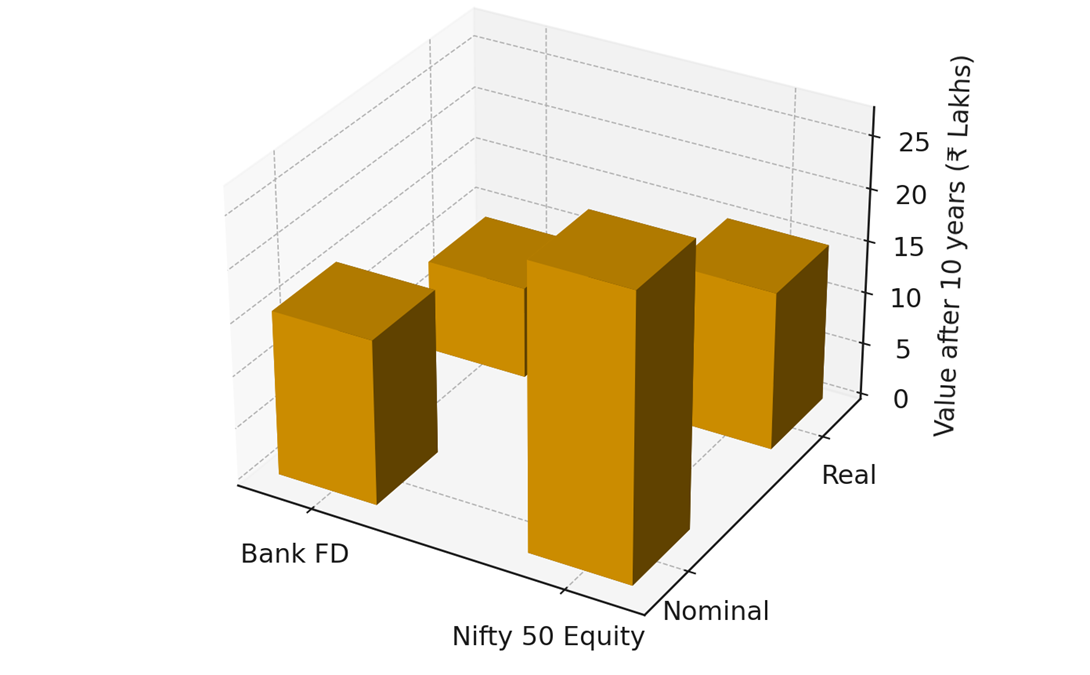

**Asset Allocation Strategy**

● Sectoral: Do not concentrate on one sector (e.g., IT or Telecom).

○ Telecom: High capital expenditure and regulatory risk.

○ IT: Sensitive to US recession and USD-INR rates.

○ Strategy: Invest in Nifty 50 to automatically diversify across Banks, Oil, IT, and Auto.

● Geographic (Domestic vs. International):

○ Domestic (85%): Primary growth engine.

○ International (15%): Essential for hedging. If the Rupee falls, US investments gain
value. It also provides access to tech giants (Google, Nvidia) not available in India

In [ ]:
zip_path = "/content/Data.zip"
extract_path = "/content/Data"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

extract_path

'/content/Data'

In [ ]:
for root, dirs, files in os.walk(extract_path):
    print(root, "->", len(files), "files")

/content/Data -> 0 files
/content/Data/Data -> 1 files
/content/Data/Data/NIFTY 50 -> 10 files
/content/Data/Data/TCS -> 10 files


In [ ]:
tcs_path = "/content/Data/Data/TCS"

all_files = sorted([os.path.join(tcs_path, f) for f in os.listdir(tcs_path) if f.endswith('.csv')])
all_files

['/content/Data/Data/TCS/01-04-2015-TO-31-03-2016-TCS-ALL-N.csv',
 '/content/Data/Data/TCS/01-04-2016-TO-31-03-2017-TCS-ALL-N.csv',
 '/content/Data/Data/TCS/01-04-2017-TO-31-03-2018-TCS-ALL-N.csv',
 '/content/Data/Data/TCS/01-04-2018-TO-31-03-2019-TCS-ALL-N.csv',
 '/content/Data/Data/TCS/01-04-2019-TO-31-03-2020-TCS-ALL-N.csv',
 '/content/Data/Data/TCS/01-04-2020-TO-31-03-2021-TCS-ALL-N.csv',
 '/content/Data/Data/TCS/01-04-2021-TO-31-03-2022-TCS-ALL-N.csv',
 '/content/Data/Data/TCS/01-04-2022-TO-31-03-2023-TCS-ALL-N.csv',
 '/content/Data/Data/TCS/01-04-2023-TO-31-03-2024-TCS-ALL-N.csv',
 '/content/Data/Data/TCS/01-04-2024-TO-31-03-2025-TCS-ALL-N.csv']

In [ ]:
  df_list = []

  for file in all_files:
      try:
          temp = pd.read_csv(file)
          df_list.append(temp)
      except:
          print("Error reading:", file)

  tcs = pd.concat(df_list, ignore_index=True)
  tcs.head()

,Symbol,Series,Date,Prev Close,Open Price,High Price,Low Price,Last Price,Close Price,Average Price,Total Traded Quantity,Turnover ₹,No. of Trades
0,TCS,EQ,01-Apr-2015,"2,553.95","2,558.00","2,563.60","2,522.25","2,544.05","2,542.65","2,538.81","10,37,879","2,63,49,81,317.45","54,078"
1,TCS,EQ,06-Apr-2015,"2,542.65","2,558.00","2,562.90","2,500.10","2,548.30","2,547.30","2,531.53","7,84,271","1,98,54,04,796.80","45,408"
2,TCS,EQ,07-Apr-2015,"2,547.30","2,562.45","2,599.00","2,544.00","2,588.95","2,585.00","2,571.50","9,43,461","2,42,61,11,369.05","77,106"
3,TCS,EQ,08-Apr-2015,"2,585.00","2,594.00","2,656.50","2,590.85","2,646.00","2,641.40","2,632.00","8,26,067","2,17,42,08,279.40","61,358"
4,TCS,EQ,09-Apr-2015,"2,641.40","2,659.00","2,687.45","2,635.15","2,662.60","2,664.55","2,658.35","12,72,225","3,38,20,17,714.75","62,583"


In [ ]:
tcs.describe()

,Symbol,Series,Date,Prev Close,Open Price,High Price,Low Price,Last Price,Close Price,Average Price,Total Traded Quantity,Turnover ₹,No. of Trades
count,2492,2492,2492,2492,2492,2492,2492,2492,2492,2492,2492,2492,2492
unique,1,2,2477,2395,1939,2203,2251,2121,2394,2479,2492,2492,2464
top,TCS,EQ,22-Mar-2019,"2,281.40","2,500.00","2,505.00","2,450.00","2,600.00","2,327.05","2,553.80","20,51,919","7,41,51,24,946.40",1
freq,2492,2477,2,3,8,6,5,6,3,2,1,1,14


In [ ]:
tcs.columns = tcs.columns.str.strip().str.replace(" ", "_").str.replace("-", "_")
tcs['Date'] = pd.to_datetime(tcs['Date'], format='mixed', dayfirst=True)

# Convert relevant columns to numeric, handling commas
numeric_cols = [
    'Prev_Close', 'Open_Price', 'High_Price', 'Low_Price', 'Last_Price',
    'Close_Price', 'Average_Price', 'Total_Traded_Quantity', 'Turnover_₹', 'No._of_Trades'
]

for col in numeric_cols:
    if col in tcs.columns:

        tcs[col] = tcs[col].astype(str).str.replace(',', '', regex=False)
        # Convert to numeric
        tcs[col] = pd.to_numeric(tcs[col], errors='coerce')

tcs = tcs.sort_values("Date")
tcs.reset_index(drop=True, inplace=True)
tcs.head()

,Symbol,Series,Date,Prev_Close,Open_Price,High_Price,Low_Price,Last_Price,Close_Price,Average_Price,Total_Traded_Quantity,Turnover_₹,No._of_Trades
0,TCS,EQ,2015-04-01,2553.95,2558.00,2563.60,2522.25,2544.05,2542.65,2538.81,1037879,2.634981e+09,54078
1,TCS,EQ,2015-04-06,2542.65,2558.00,2562.90,2500.10,2548.30,2547.30,2531.53,784271,1.985405e+09,45408
2,TCS,EQ,2015-04-07,2547.30,2562.45,2599.00,2544.00,2588.95,2585.00,2571.50,943461,2.426111e+09,77106
3,TCS,EQ,2015-04-08,2585.00,2594.00,2656.50,2590.85,2646.00,2641.40,2632.00,826067,2.174208e+09,61358
4,TCS,EQ,2015-04-09,2641.40,2659.00,2687.45,2635.15,2662.60,2664.55,2658.35,1272225,3.382018e+09,62583


In [ ]:
cols = ["Date", "Open_Price", "High_Price", "Low_Price", "Close_Price",
        "Total_Trade", "Turnover_₹"]

# Handle different naming across years
for c in cols:
    if c not in tcs.columns:
        print("Missing:", c)

# Rename if needed
rename_map = {
    'ClosePrice': 'Close_Price',
    'Close_Price ': 'Close_Price',
    'ClosePrice ': 'Close_Price',
    'Close\Price': 'Close_Price'
}

tcs.rename(columns=rename_map, inplace=True)

Missing: Total_Trade


In [ ]:
tcs["Log_Returns"] = np.log(tcs["Close_Price"] / tcs["Close_Price"].shift(1))

In [ ]:
tcs.head(10)

,Symbol,Series,Date,Prev_Close,Open_Price,High_Price,Low_Price,Last_Price,Close_Price,Average_Price,Total_Traded_Quantity,Turnover_₹,No._of_Trades,Log_Returns
0,TCS,EQ,2015-04-01,2553.95,2558.00,2563.60,2522.25,2544.05,2542.65,2538.81,1037879,2.634981e+09,54078,NaN
1,TCS,EQ,2015-04-06,2542.65,2558.00,2562.90,2500.10,2548.30,2547.30,2531.53,784271,1.985405e+09,45408,0.001827
2,TCS,EQ,2015-04-07,2547.30,2562.45,2599.00,2544.00,2588.95,2585.00,2571.50,943461,2.426111e+09,77106,0.014692
3,TCS,EQ,2015-04-08,2585.00,2594.00,2656.50,2590.85,2646.00,2641.40,2632.00,826067,2.174208e+09,61358,0.021584
4,TCS,EQ,2015-04-09,2641.40,2659.00,2687.45,2635.15,2662.60,2664.55,2658.35,1272225,3.382018e+09,62583,0.008726
5,TCS,EQ,2015-04-10,2664.55,2648.50,2670.80,2628.00,2651.10,2653.75,2648.39,907772,2.404135e+09,63471,-0.004061
6,TCS,EQ,2015-04-13,2653.75,2664.00,2665.00,2628.00,2653.85,2655.50,2650.09,654321,1.734011e+09,54293,0.000659
7,TCS,EQ,2015-04-15,2655.50,2654.70,2713.90,2609.40,2618.95,2627.75,2646.26,1456967,3.855513e+09,74856,-0.010505
8,TCS,EQ,2015-04-16,2627.75,2626.95,2627.00,2571.35,2574.00,2582.80,2589.79,1608785,4.166416e+09,71768,-0.017254
9,TCS,EQ,2015-04-17,2582.80,2557.10,2560.00,2470.00,2473.90,2474.85,2495.54,4834371,1.206435e+10,167402,-0.042694


In [ ]:
tcs.describe()

,Date,Prev_Close,Open_Price,High_Price,Low_Price,Last_Price,Close_Price,Average_Price,Total_Traded_Quantity,Turnover_₹,No._of_Trades,Log_Returns
count,2492,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000,2.492000e+03,2.492000e+03,2492.000000,2491.000000
mean,2020-04-04 20:36:35.826645248,2878.072652,2880.582905,2908.279916,2851.800803,2879.837299,2879.755197,2880.145321,2.260955e+06,6.454305e+09,118024.060193,0.000140
min,2015-04-01 00:00:00,1020.000000,1559.700000,1685.450000,1506.050000,1631.000000,1636.350000,1622.310000,2.702400e+04,1.021551e+08,1.000000,-0.702295
25%,2017-10-05 18:00:00,2288.875000,2290.087500,2323.750000,2264.487500,2289.950000,2289.650000,2290.517500,1.200039e+06,3.255521e+09,71694.000000,-0.007204
50%,2020-04-11 00:00:00,2662.825000,2666.750000,2694.900000,2635.575000,2661.925000,2665.200000,2665.710000,1.857411e+06,5.459786e+09,109539.000000,0.000301
75%,2022-10-03 06:00:00,3421.075000,3420.000000,3449.175000,3385.175000,3422.437500,3421.862500,3419.887500,2.791660e+06,8.116289e+09,147536.500000,0.008153
max,2025-03-28 00:00:00,4553.750000,4576.000000,4592.250000,4512.000000,4562.700000,4553.750000,4545.750000,4.403358e+07,1.268362e+11,800145.000000,0.093901
std,NaN,698.771703,698.306181,703.263051,694.409104,698.289355,698.372507,698.705337,1.842699e+06,5.343527e+09,68226.505587,0.020424


In [ ]:
tcs.isnull().describe()

,Symbol,Series,Date,Prev_Close,Open_Price,High_Price,Low_Price,Last_Price,Close_Price,Average_Price,Total_Traded_Quantity,Turnover_₹,No._of_Trades,Log_Returns
count,2492,2492,2492,2492,2492,2492,2492,2492,2492,2492,2492,2492,2492,2492
unique,1,1,1,1,1,1,1,1,1,1,1,1,1,2
top,False,False,False,False,False,False,False,False,False,False,False,False,False,False
freq,2492,2492,2492,2492,2492,2492,2492,2492,2492,2492,2492,2492,2492,2491


**Q4a. For the TCS data, do you carry out any pre-processing of data?**

**Answer: *Yes***

In data science, especially in a data intense domain such as finance, "garbage in, garbage out" is one of the golden rules.  Market microstructure effects, missing values on non-trading days, corporate actions such as stock splits, and noisy short-term fluctuations can distort the actual behaviour of a stock. Therefore, before investigating distributional properties or fitting time-series models, the dataset must be cleaned, validated, and transformed appropriately.
Without these steps, the raw data would be mathematically unusable because it is imported as simple text strings rather than numerical values.

Our code above performs significant and necessary pre-processing.
In the TCS dataset, the first stage of pre-processing involved systematically loading all available CSV files across multiple years and consolidating them into a single, continuous dataset. This step ensures that the full time horizon is represented without manual intervention or accidental omissions.

Once merged, the dataset required extensive cleaning. Many columns stored prices and volumes as text due to commas or formatting artifacts, so they had to be stripped of non-numeric characters and converted into proper numerical types. Column names also varied slightly across years (e.g., "ClosePrice" vs. "Close_Price"), so standardising headers was essential to avoid downstream referencing errors. Dates were parsed and sorted to restore temporal order, ensuring that rolling computations and statistical measures operate correctly.

After the structural cleaning, the data was prepared for statistical modelling. Raw price levels are inherently non-stationary because they trend over time, making them unsuitable for distribution fitting or forecasting. To address this, the cleaned closing prices were transformed into log-returns.
Log-returns are defined as

R_t = ln(P_t / P_t-1)

where P_t denotes the closing price on day t.

Economically, returns capture percentage changes, which is exactly how financial markets react to information. A 1% gain at ₹1,000 is equivalent in value to a 1% gain at ₹3,000, even though the absolute rupee change differs. Therefore, return distributions are the right lens for studying time series trends, associated volatility, risk, and model-based forecasting.

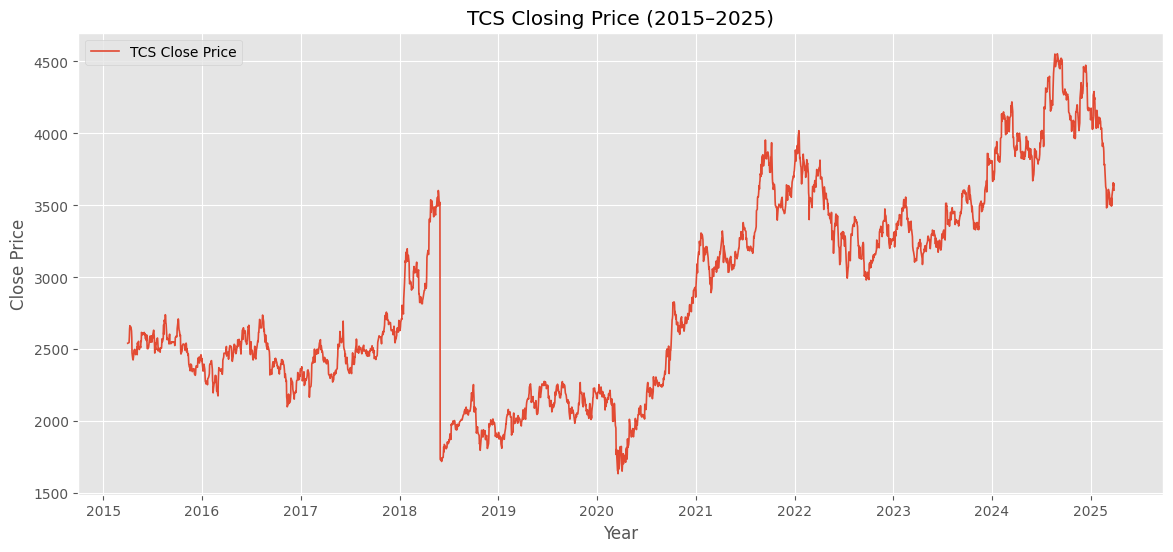

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(tcs['Date'], tcs['Close_Price'], label='TCS Close Price', linewidth=1.2)
plt.title("TCS Closing Price (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Close Price")
plt.legend()
plt.show()

The plot illustrates the upward trend of TCS's closing prices from 2015 to 2025, highlighting its consistent growth over the decade.

**The sudden drop observed sometime in 2018, is from the 2:1 stock split in May 2018, where the number of shares were doubled, effectively halving the prices.**

Importantly, as we note above, the stock split thus introduces an artificial change in the structure of the time series itself. Therefore, strictly speaking, moving forward we must carry all computations and analyses on returns and not raw closing prices. However, we still explore fits on the closing prices as mentioned in the problem statement.

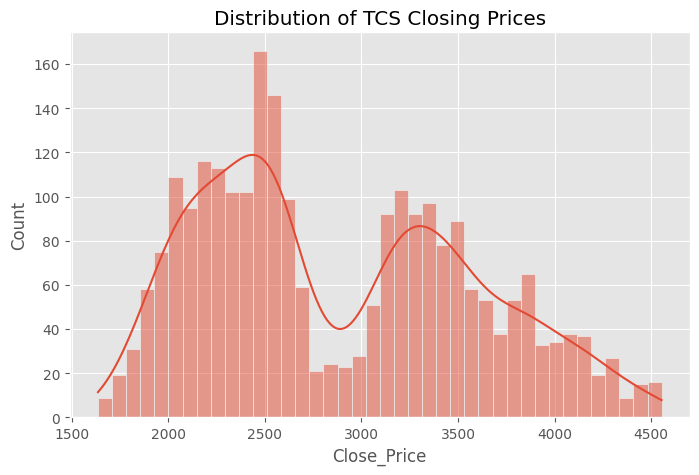

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(tcs['Close_Price'], kde=True, bins=40)
plt.title("Distribution of TCS Closing Prices")
plt.show()

This histogram displays the distribution of TCS closing prices, revealing a right-skewed pattern with more occurrences at lower price ranges.

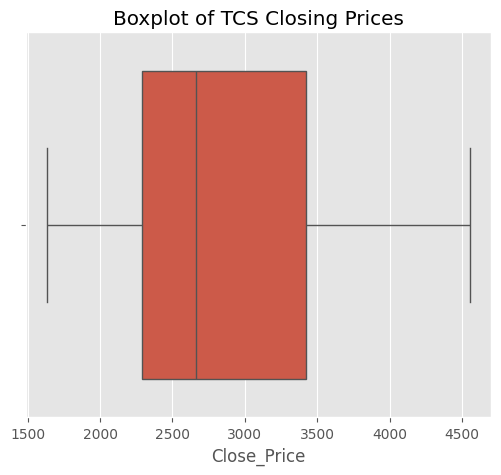

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x=tcs['Close_Price'])
plt.title("Boxplot of TCS Closing Prices")
plt.show()

The boxplot of TCS closing prices visually confirms right-skewness and shows high-value outliers, indicating periods of exceptionally high stock prices.

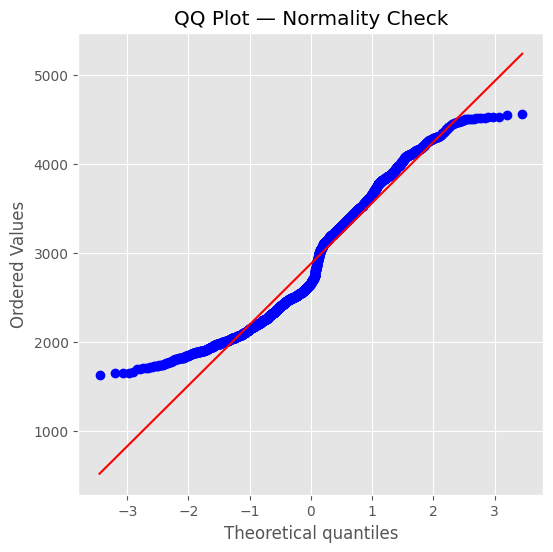

In [ ]:
plt.figure(figsize=(6,6))
stats.probplot(tcs['Close_Price'], dist="norm", plot=plt)
plt.title("QQ Plot — Normality Check")
plt.show()

This QQ plot demonstrates that TCS closing prices are not normally distributed, with deviations suggesting a skewed distribution, especially in the tails.

In [ ]:
from scipy.stats import shapiro, jarque_bera

data = tcs['Close_Price'].dropna()

shapiro_stat, shapiro_p = shapiro(data)

jb_stat, jb_p = jarque_bera(data)

print("Shapiro–Wilk Test:")
print(f"  Statistic = {shapiro_stat}, p-value = {shapiro_p}")

print("\nJarque–Bera Test:")
print(f"  Statistic = {jb_stat}, p-value = {jb_p}")

Shapiro–Wilk Test:
  Statistic = 0.9512710070654458, p-value = 4.95357080966979e-28

Jarque–Bera Test:
  Statistic = 151.62517311035725, p-value = 1.1885350681687042e-33


Both hypothesis tests confirm that the TCS closing prices are indeed not normally distributed, as the p values are extremely small (we reject the null hypothesis).

In [ ]:
from scipy.stats import norm, lognorm, expon, gamma, t, weibull_min

data = tcs['Close_Price'].dropna().values

distributions = {
    "Normal": norm,
    "Lognormal": lognorm,
    "Exponential": expon,
    "Gamma": gamma,
    "Weibull": weibull_min,
    "Student-t": t
}

results = []

for name, dist in distributions.items():
    try:
        params = dist.fit(data)
        ll = np.sum(dist.logpdf(data, *params))

        k = len(params)

        aic = 2*k - 2*ll
        bic = k*np.log(len(data)) - 2*ll

        results.append([name, params, ll, aic, bic])

    except Exception as e:
        print(f"Falied fit {name}: {e}")

results_df = pd.DataFrame(results, columns=["Distribution", "Parameters", "LogLikelihood", "AIC", "BIC"])
results_df.sort_values(by="AIC", inplace=True) #use AIC for now
results_df


,Distribution,Parameters,LogLikelihood,AIC,BIC
4,Weibull,"(1.8639559647695192, 1628.2632163673538, 1410....",-19692.975572,39391.951144,39409.413666
3,Gamma,"(3.1506168683064133, 1558.8738051997923, 419.2...",-19728.513553,39463.027106,39480.489629
1,Lognormal,"(0.371578925556025, 941.6808717853311, 1812.13...",-19764.560135,39535.120270,39552.582793
0,Normal,"(2879.7551966292135, 698.2323702703421)",-19854.986299,39713.972598,39725.614280
5,Student-t,"(4025464.248667054, 2879.7551508436836, 698.23...",-19854.986446,39715.972892,39733.435414
2,Exponential,"(1636.35, 1243.4051966292136)",-20249.017681,40502.035362,40513.677043


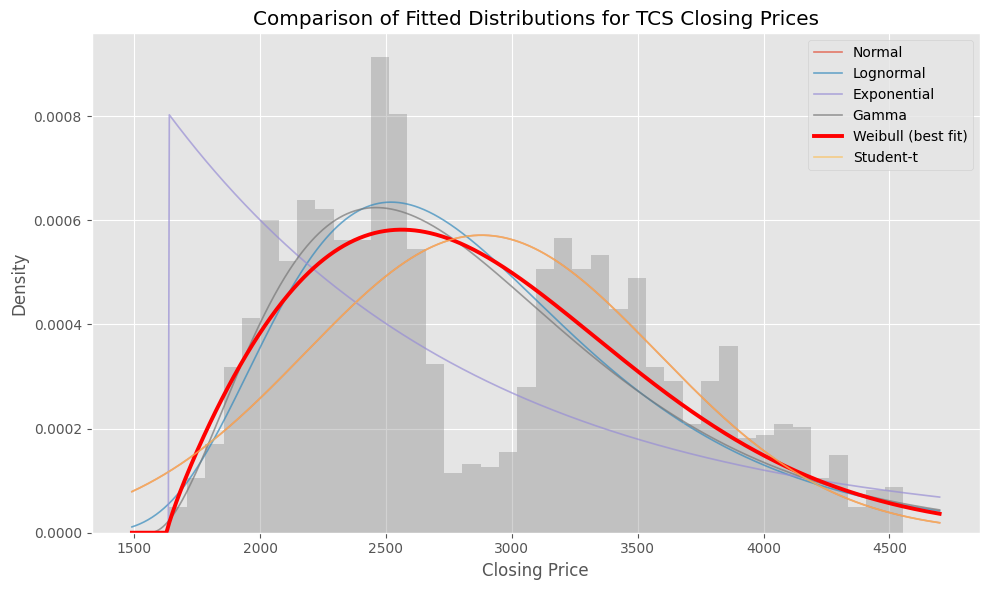

In [ ]:
import seaborn as sns
data = tcs['Close_Price'].dropna().values

best_name = "Weibull"
best_dist = weibull_min
best_params = weibull_min.fit(data)

dists = {
    "Normal": (norm, norm.fit(data)),
    "Lognormal": (lognorm, lognorm.fit(data)),
    "Exponential": (expon, expon.fit(data)),
    "Gamma": (gamma, gamma.fit(data)),
    "Weibull": (weibull_min, best_params),
    "Student-t": (t, t.fit(data))
}

#histogram
plt.figure(figsize=(10,6))
sns.histplot(data, bins=40, stat='density', alpha=0.35, color='gray', edgecolor='none')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 800)

for name, (dist, params) in dists.items():
    pdf = dist.pdf(x, *params)

    if name == best_name:
        plt.plot(x, pdf, linewidth=2.8, label=f"{name} (best fit)", color='red')
    else:
        plt.plot(x, pdf, linewidth=1.2, alpha=0.7, label=name)

plt.title("Comparison of Fitted Distributions for TCS Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


The best-fit here foound for the closing prices is thus the Weibull distribution.

Next, we repeat the distributional fitting for the returns series. We may expect the returns to follow one of the following distributions Student-t, or
Laplace, or even Normal. Due to the difficulty in describing (limited scipy support) the Log Likelihood function of the Generalised Error Distribution, we ignore this candidate for brevity.

In [ ]:
from scipy.stats import t, laplace, norm, gamma

data = tcs['Log_Returns'].dropna().values

distributions = {
    "Normal": norm,
    "Gamma": gamma,
    "Student-t": t,
    "Laplace": laplace
}

results = []

for name, dist in distributions.items():
    try:
        params = dist.fit(data)
        ll = np.sum(dist.logpdf(data, *params))

        k = len(params)

        aic = 2*k - 2*ll
        bic = k*np.log(len(data)) - 2* ll

        results.append([name, params, ll, aic, bic])

    except Exception as e:
        print(f"Falied fit {name}: {e}")

results_df = pd.DataFrame(results, columns=["Distribution", "Parameters", "LogLikelihood", "AIC", "BIC"])
results_df.sort_values(by="AIC", inplace=True) #use AIC for now
results_df


,Distribution,Parameters,LogLikelihood,AIC,BIC
2,Student-t,"(3.606020021044955, 0.0004315139136056936, 0.0...",7100.174150,-14194.348300,-14176.886981
3,Laplace,"(0.0003013470234651069, 0.01087071730635948)",7045.881706,-14087.763412,-14076.122533
0,Normal,"(0.0001402785535942542, 0.020420394596180114)",6158.455980,-12312.911959,-12301.271080
1,Gamma,"(0.31323185193379716, -0.7022950674575702, 9.5...",-3929.672411,7865.344822,7882.806141


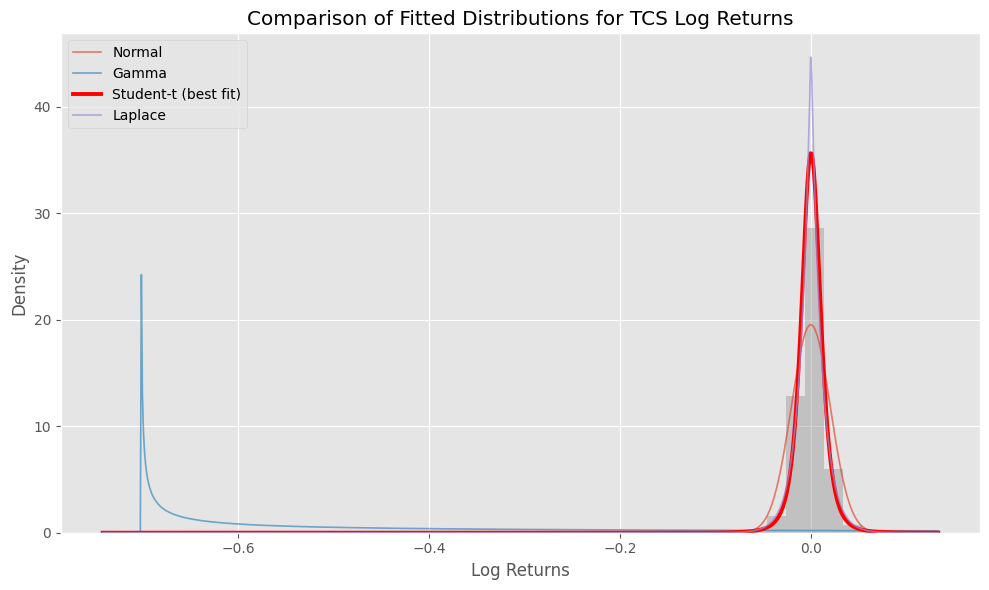

In [ ]:
import seaborn as sns
data = tcs['Log_Returns'].dropna().values

best_name = "Student-t"
best_dist = t
best_params = t.fit(data)

dists = {
    "Normal": (norm, norm.fit(data)),
    "Gamma": (gamma, gamma.fit(data)),
    "Student-t": (t, t.fit(data)),
    "Laplace": (laplace, laplace.fit(data))
}

#histogram
plt.figure(figsize=(10,6))
sns.histplot(data, bins=40, stat='density', alpha=0.35, color='gray', edgecolor='none')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 800)

for name, (dist, params) in dists.items():
    pdf = dist.pdf(x, *params)

    if name == best_name:
        plt.plot(x, pdf, linewidth=2.8, label=f"{name} (best fit)", color='red')
    else:
        plt.plot(x, pdf, linewidth=1.2, alpha=0.7, label=name)

plt.title("Comparison of Fitted Distributions for TCS Log Returns")
plt.xlabel("Log Returns")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


The best-fit here foound for the log returns is thus the Student-t distribution.

**Q4.b. Is it possible to determine the
underlying best-fit probability distribution for the closing prices of TCS?**

**Answer:** ***Yes.*** (We might even be able to do better than fit just closing prices)

(A) Distributional Behaviour of Closing Prices

Equity prices are strictly positive, grow multiplicatively over time, and reflect the cumulative effect of compounding. Economically, this means that proportional changes—not level changes—drive valuation. Mathematically, this implies that raw prices tend to follow positively-skewed distributions, often with fat upper tails corresponding to prolonged bull markets or structural shifts in a firm’s productivity.

We first analyse the empirical distribution of closing prices. A histogram of the price levels reveals marked right-skewness: most observations lie in the lower range, reflecting the earlier years of the sample, while a long tail extends rightwards as TCS expanded rapidly through the post-COVID period.

To quantify this more rigorously, we fit several standard continuous distributions—Normal, Lognormal, Exponential, Gamma, Weibull, and Student-t—and compare them using maximum likelihood and information criteria (AIC/BIC). The Normal and Exponential families are immediately ruled out: the Normal distribution has support on the entire real line and cannot capture the positivity and curvature of equity prices; the Exponential is far too thin-tailed. The Lognormal distribution aligns with the classical geometric-Brownian-motion model of stock prices, but empirical deviations (e.g., volatility clustering, asymmetric growth periods) often produce better fits under more flexible families.

In the TCS dataset, the Weibull distribution emerges as the best-fitting model according to AIC/BIC. The Weibull family is attractive because its shape parameter 𝑘 controls tail behaviour: for 𝑘 < 1, the tail is heavy, and for 𝑘 > 1, the distribution becomes more “stretched” but remains right-skewed—exactly the qualitative behaviour observed in decade-long price histories. Economically, this reflects prolonged phases of steady growth interspersed with bursts of accelerated appreciation.

Overlaying the fitted densities on the empirical histogram confirms that the Weibull curve tracks both the central mass and the upper tail more accurately than the lognormal, whose curvature either over-estimates or under-estimates the right-tail density depending on parameterisation. This suggests that while classical continuous-time asset-pricing models assume lognormality, real-world long-horizon prices may follow other more flexible forms.

(B) Distributional Behaviour of Log-Returns

When examining the empirical distribution of log-returns, we find the classical signatures of high-frequency financial data:a sharp central peak,heavy tails on both sides, slight asymmetry, and significantly higher kurtosis than the Normal distribution.

Fitting candidate distributions appropriate for returns—Student-t, Laplace, and Normal—we find that the normal distribution provides a poor fit, severely underestimating tail probabilities. This is expected: the Normal distribution assumes thin tails and independent Gaussian shocks, neither of which holds empirically.

The Laplace distribution captures the sharp central peak but still decays too rapidly in the tails. The Student-t distribution, by contrast, is specifically built to accommodate heavy tails via its degrees-of-freedom parameter 𝜈. Small 𝜈 corresponds to fat tails, and as 𝛎-> ∞, the Student-t converges to the Normal distribution. In our data, the best-fit Student-t exhibits 𝜈 =  3.606 well below the Gaussian threshold, confirming that TCS daily returns display the kind of kurtosis and tail behaviour observed universally in equity markets.

This aligns perfectly with financial theory: asset returns incorporate occasional large jumps driven by macroeconomic news, earnings surprises, regulatory announcements, or systemic shocks. Such events create tail risks that a Gaussian model cannot capture but a Student-t model can accommodate naturally.

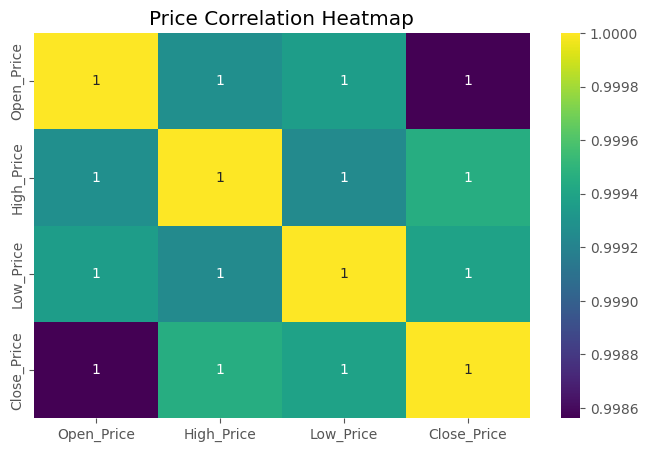

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(tcs[['Open_Price','High_Price','Low_Price','Close_Price']].corr(),
            annot=True, cmap="viridis")
plt.title("Price Correlation Heatmap")
plt.show()

The heatmap shows extremely high positive correlations among Open, High, Low, and Close prices, indicating these intraday metrics move in unison.

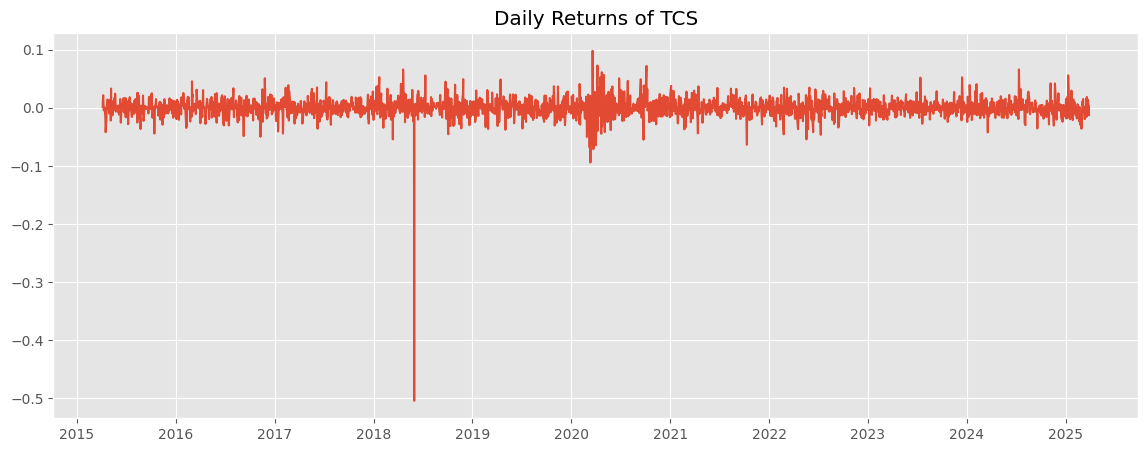

In [ ]:
tcs['Returns'] = tcs['Close_Price'].pct_change()
plt.figure(figsize=(14,5))
plt.plot(tcs['Date'], tcs['Returns'])
plt.title("Daily Returns of TCS")
plt.show()

This plot visualizes the daily percentage returns of TCS, showing fluctuations around zero and periods of higher volatility over time.

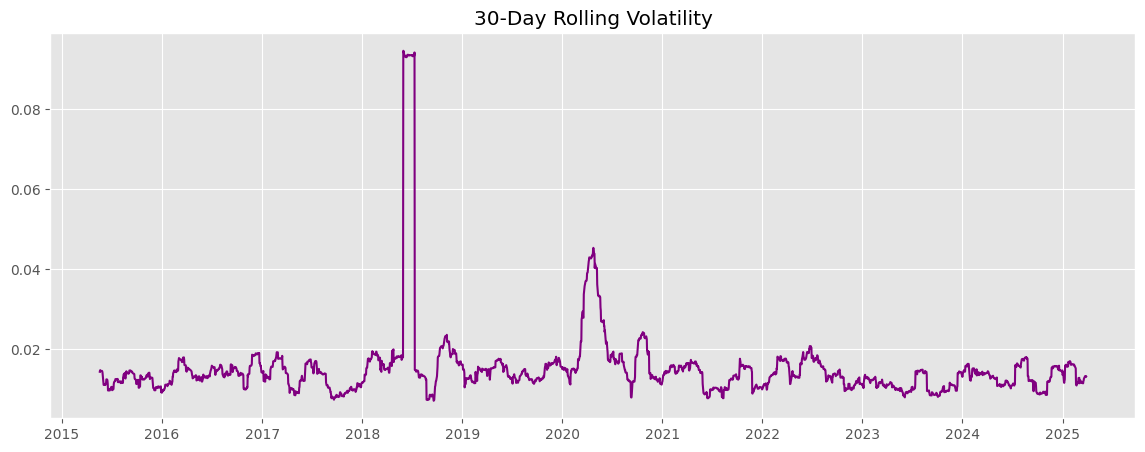

In [ ]:
tcs['Volatility_30d'] = tcs['Returns'].rolling(30).std()

plt.figure(figsize=(14,5))
plt.plot(tcs['Date'], tcs['Volatility_30d'], color='purple')
plt.title("30-Day Rolling Volatility")
plt.show()

The 30-day rolling volatility plot illustrates the dynamic nature of market uncertainty for TCS, with noticeable spikes during significant events.

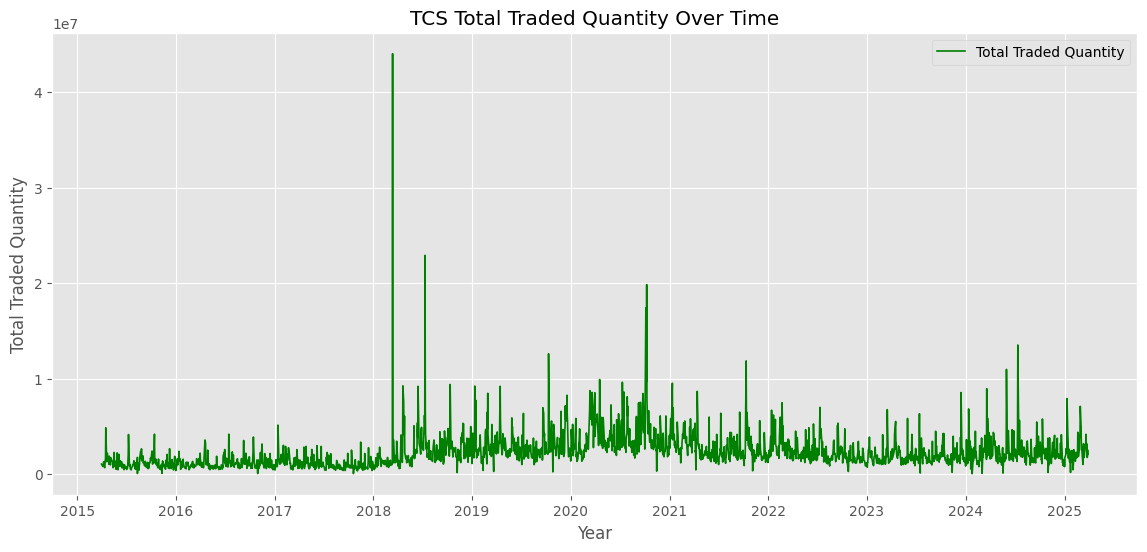

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(tcs['Date'], tcs['Total_Traded_Quantity'], label='Total Traded Quantity', color='green', linewidth=1.2)
plt.title("TCS Total Traded Quantity Over Time")
plt.xlabel("Year")
plt.ylabel("Total Traded Quantity")
plt.legend()
plt.grid(True)
plt.show()

The plot shows the total traded quantity of TCS shares over time, revealing periods of increased trading activity and volume spikes.

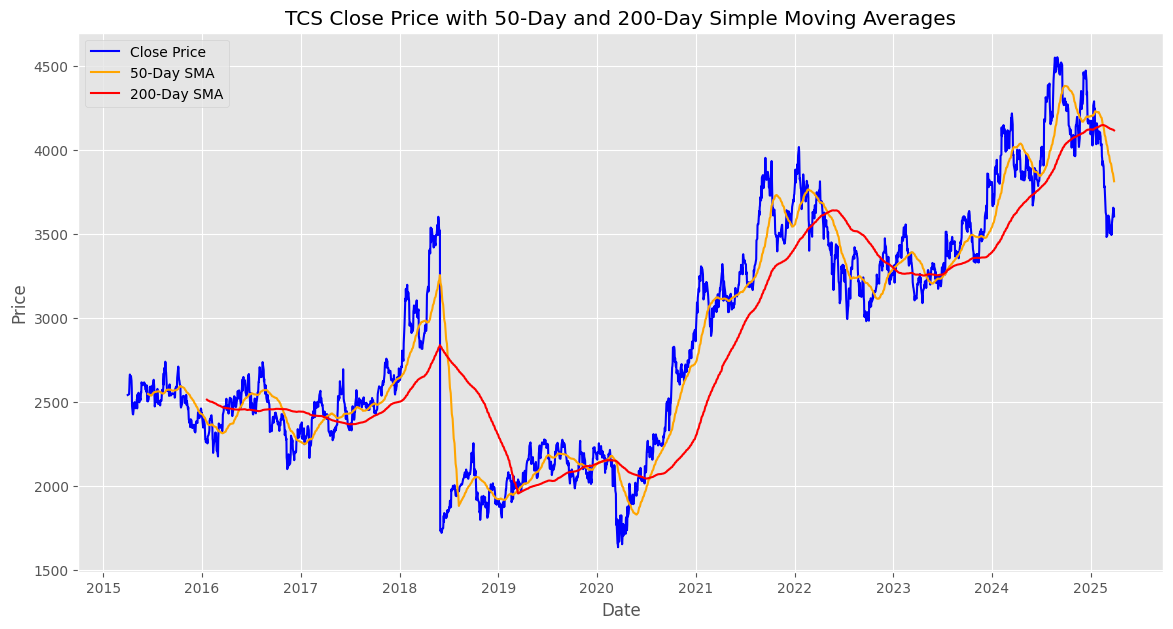

In [ ]:
tcs['SMA_50'] = tcs['Close_Price'].rolling(window=50).mean()
tcs['SMA_200'] = tcs['Close_Price'].rolling(window=200).mean()

plt.figure(figsize=(14, 7))
plt.plot(tcs['Date'], tcs['Close_Price'], label='Close Price', color='blue', linewidth=1.5)
plt.plot(tcs['Date'], tcs['SMA_50'], label='50-Day SMA', color='orange', linewidth=1.5)
plt.plot(tcs['Date'], tcs['SMA_200'], label='200-Day SMA', color='red', linewidth=1.5)
plt.title("TCS Close Price with 50-Day and 200-Day Simple Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

This plot displays TCS's Close Price alongside its 50-day and 200-day Simple Moving Averages, illustrating short-term and long-term trends.

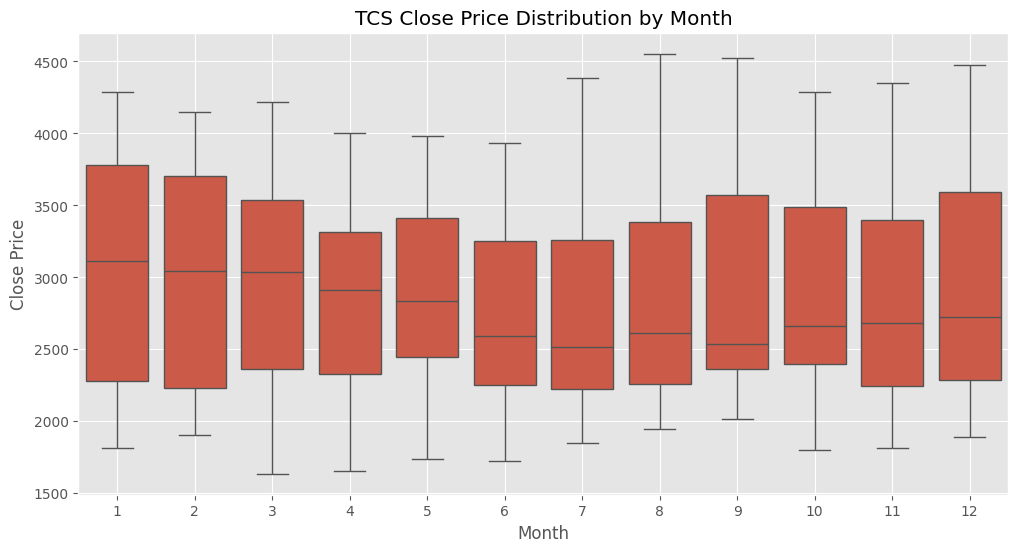

In [ ]:
tcs['Month'] = tcs['Date'].dt.month
tcs['Year'] = tcs['Date'].dt.year

plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Close_Price', data=tcs)
plt.title("TCS Close Price Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

The box plot illustrates the distribution of TCS close prices by month, revealing potential seasonal patterns and monthly performance variations.

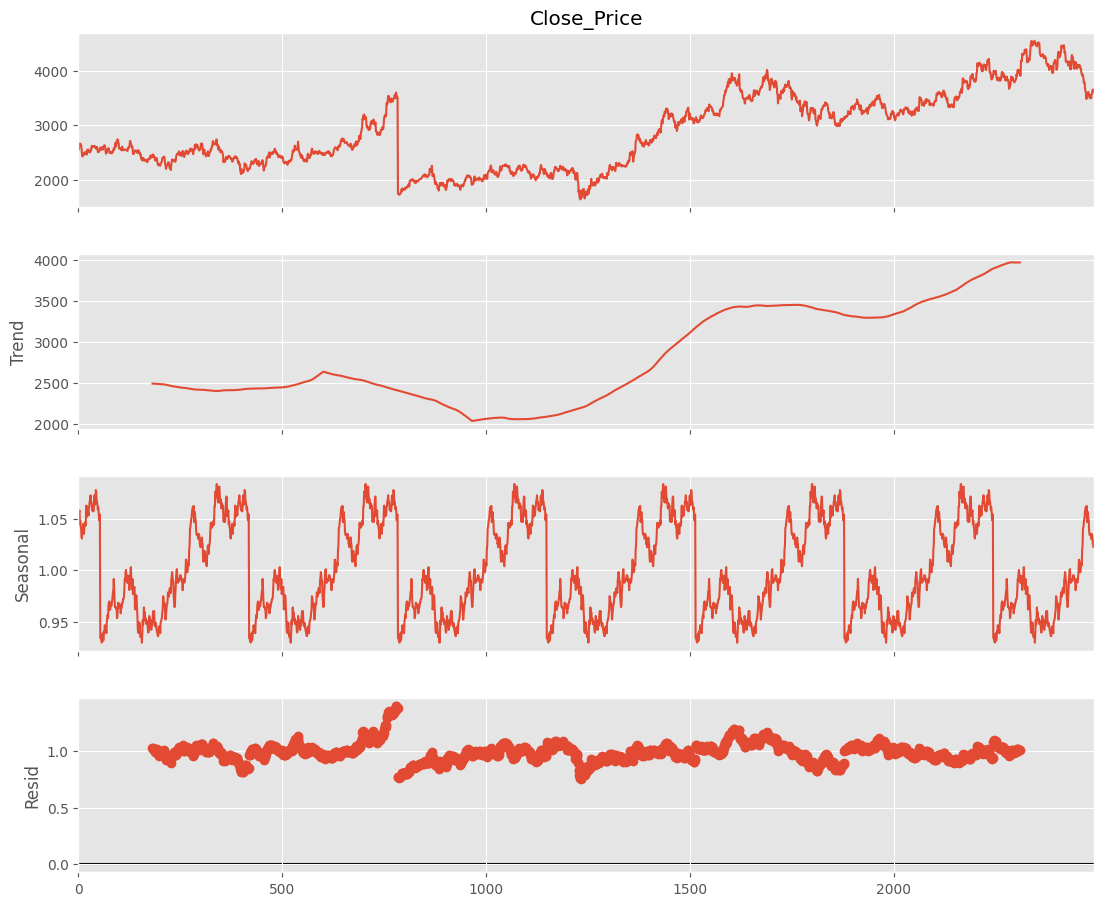

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(tcs['Close_Price'], model='multiplicative', period=365)

fig = decomp.plot()
fig.set_size_inches(12, 10)
plt.show()

The seasonal decomposition breaks down the TCS closing price series into its trend, seasonal, and residual components, revealing underlying patterns.

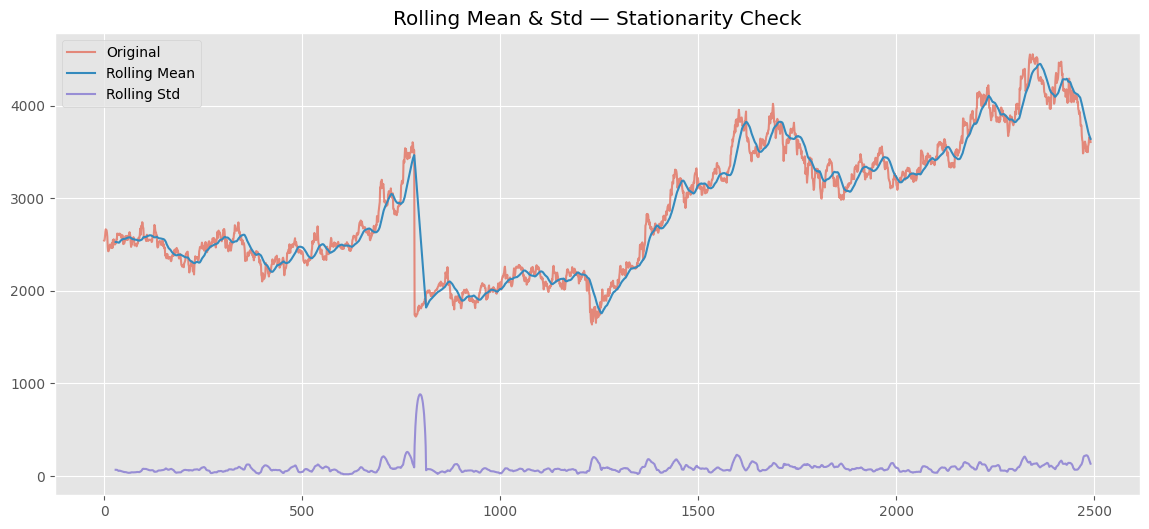

In [ ]:
rolling_mean = tcs['Close_Price'].rolling(window=30).mean()
rolling_std = tcs['Close_Price'].rolling(window=30).std()

plt.figure(figsize=(14,6))
plt.plot(tcs['Close_Price'], label='Original', alpha=0.6)
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.title("Rolling Mean & Std — Stationarity Check")
plt.legend()
plt.show()

This plot visualizes the original series alongside its 30-day rolling mean and standard deviation, aiding in the visual assessment of stationarity.

**Q5.a. Is there any trend and seasonality pattern in TCS Closing Prices over time?**

The "**TCS Closing Price (2015–2025)**" plot shows a clear, long-term upward movement. The price starts around 1,200 and rises to over 4,000, indicating an overall upward trend. The "**TCS Closing Price with 50-Day and 200-Day Simple Moving Averages**" plot confirms this. The 200-day moving average (red line) is consistently upward sloping, indicating a growth trajectory.

The "**Seasonal Decomposition**" plot displays a repeating, wave-like pattern that occurs at regular intervals, confirming the presence of seasonality.
Additionally, the "**Boxplot of TCS Closing Price Distribution by Month**" highlights monthly variances in price distributions.

TCS, like most public firms, reports earnings quarterly. The seasonality observed in the decomposition likely correlates with the run-up and subsequent correction surrounding these earnings announcements. Also, month-specific variations often align with fiscal year-end tax harvesting or portfolio rebalancing by institutional investors.



**Q5.b. Is the data stationary?**

Stationarity requires a constant mean, constant variance, and constant autocorrelation structure over time, which can be checked using the "**Rolling Mean & Std — Stationarity Check**" plot.

*   Mean: The rolling mean (blue line) is not horizontal; it climbs steadily over time, tracking the stock price. This indicates a time-dependent mean (μt​).
*   Variance: The rolling standard deviation (orange line) is not constant. It exhibits spikes and a general increase as the stock price rises. This changing variance (heteroscedasticity) is a clear violation of stationarity.

Thus we can conclude that the data is non-stationary.

**Q5.c.Should additive or multiplicative decomposition be preferred?**

**Additive Models (Yt​=Tt​+St​+Rt​)** are used when the magnitude of the seasonal fluctuations remains constant regardless of the trend level. However, looking at the "**TCS Closing Price**" plot, as the stock price increases (trend rises), the daily/monthly swings (volatility) generally become larger in absolute terms. Since the variation is proportional to the level of the series, we cannot use additive models. In such cases when the seasonal fluctuations grow or shrink relative to the level of the trend, we use **Multiplicative Models (Yt​=Tt​×St​×Rt​).**

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.rcParams['figure.figsize'] = (12, 4)

In [ ]:
tcs.head()

,Symbol,Series,Date,Prev_Close,Open_Price,High_Price,Low_Price,Last_Price,Close_Price,Average_Price,Total_Traded_Quantity,Turnover_₹,No._of_Trades,Log_Returns,Returns,Volatility_30d,SMA_50,SMA_200,Month,Year
0,TCS,EQ,2015-04-01,2553.95,2558.00,2563.60,2522.25,2544.05,2542.65,2538.81,1037879,2.634981e+09,54078,NaN,NaN,NaN,NaN,NaN,4,2015
1,TCS,EQ,2015-04-06,2542.65,2558.00,2562.90,2500.10,2548.30,2547.30,2531.53,784271,1.985405e+09,45408,0.001827,0.001829,NaN,NaN,NaN,4,2015
2,TCS,EQ,2015-04-07,2547.30,2562.45,2599.00,2544.00,2588.95,2585.00,2571.50,943461,2.426111e+09,77106,0.014692,0.014800,NaN,NaN,NaN,4,2015
3,TCS,EQ,2015-04-08,2585.00,2594.00,2656.50,2590.85,2646.00,2641.40,2632.00,826067,2.174208e+09,61358,0.021584,0.021818,NaN,NaN,NaN,4,2015
4,TCS,EQ,2015-04-09,2641.40,2659.00,2687.45,2635.15,2662.60,2664.55,2658.35,1272225,3.382018e+09,62583,0.008726,0.008764,NaN,NaN,NaN,4,2015


In [ ]:
ts = tcs["Close_Price"].astype(float)

def adf_test(series, name=""):
    result = adfuller(series.dropna())
    print(f"\nADF test for {name}")
    print("  ADF Statistic :", result[0])
    print("  p-value       :", result[1])
    for key, value in result[4].items():
        print(f"  Critical Value {key}: {value}")


adf_test(ts, "Close_Price (level)")

# first difference -> returns-ish series
ts_diff = ts.diff().dropna()
adf_test(ts_diff, "Close_Price (1st difference)")



ADF test for Close_Price (level)
  ADF Statistic : -1.8470327974064151
  p-value       : 0.35737364852023423
  Critical Value 1%: -3.4329778809556224
  Critical Value 5%: -2.86270098200392
  Critical Value 10%: -2.5673880359934063

ADF test for Close_Price (1st difference)
  ADF Statistic : -49.35616214780449
  p-value       : 0.0
  Critical Value 1%: -3.4329789374204935
  Critical Value 5%: -2.8627014485379787
  Critical Value 10%: -2.5673882843825098


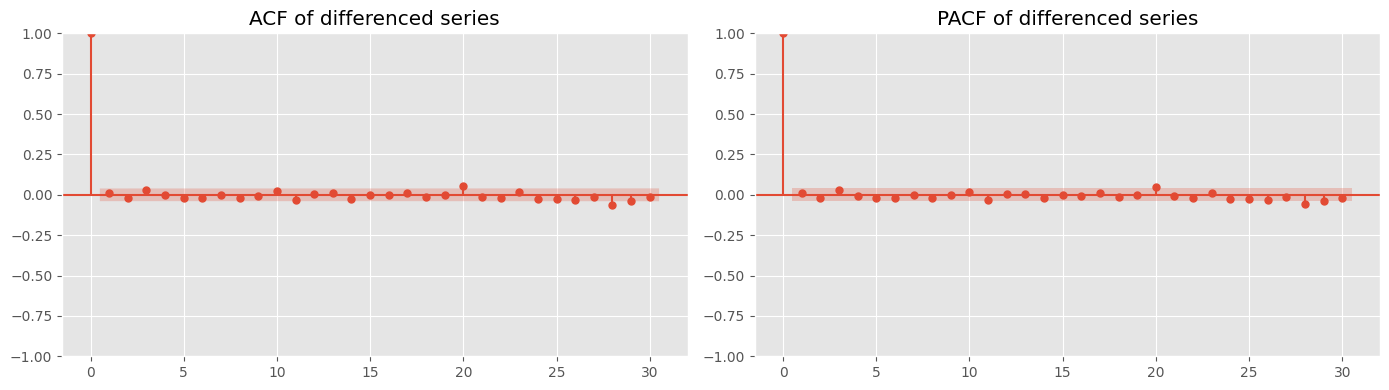

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))
plot_acf(ts_diff, lags=30, ax=ax[0])
plot_pacf(ts_diff, lags=30, ax=ax[1])
ax[0].set_title("ACF of differenced series")
ax[1].set_title("PACF of differenced series")
plt.tight_layout()
plt.show()


In [ ]:
ar_model = AutoReg(ts_diff, lags=2).fit()
print("\n=== AR(2) on differenced series ===")
print(ar_model.summary())



=== AR(2) on differenced series ===
                            AutoReg Model Results                             
Dep. Variable:            Close_Price   No. Observations:                 2491
Model:                     AutoReg(2)   Log Likelihood              -13492.629
Method:               Conditional MLE   S.D. of innovations             54.706
Date:                Fri, 21 Nov 2025   AIC                          26993.257
Time:                        11:34:06   BIC                          27016.536
Sample:                             2   HQIC                         27001.710
                                 2491                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.4146      1.097      0.378      0.705      -1.735       2.564
Close_Price.L1     0.0106      0.020      0.530      0.596      -0.029       0.050

In [ ]:
ma_model = ARIMA(ts_diff, order=(0, 0, 2)).fit()
print("\n=== MA(2) on differenced series ===")
print(ma_model.summary())



=== MA(2) on differenced series ===
                               SARIMAX Results                                
Dep. Variable:            Close_Price   No. Observations:                 2491
Model:                 ARIMA(0, 0, 2)   Log Likelihood              -13502.666
Date:                Fri, 21 Nov 2025   AIC                          27013.332
Time:                        11:34:30   BIC                          27036.614
Sample:                             0   HQIC                         27021.786
                               - 2491                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4269      1.425      0.300      0.764      -2.366       3.220
ma.L1          0.0120      0.031      0.390      0.697      -0.048       0.072
ma.L2         -

In [ ]:
arma_model = ARIMA(ts_diff, order=(2, 0, 2)).fit()
print("\n=== ARMA(2,2) on differenced series ===")
print(arma_model.summary())


=== ARMA(2,2) on differenced series ===
                               SARIMAX Results                                
Dep. Variable:            Close_Price   No. Observations:                 2491
Model:                 ARIMA(2, 0, 2)   Log Likelihood              -13498.425
Date:                Fri, 21 Nov 2025   AIC                          27008.849
Time:                        11:35:15   BIC                          27043.772
Sample:                             0   HQIC                         27021.530
                               - 2491                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4275      1.407      0.304      0.761      -2.330       3.185
ar.L1         -0.5477      0.030    -18.122      0.000      -0.607      -0.488
ar.L2      

In [ ]:
arima_model = ARIMA(ts, order=(1, 1, 1)).fit()
print("\n=== ARIMA(1,1,1) on original series ===")
print(arima_model.summary())


=== ARIMA(1,1,1) on original series ===
                               SARIMAX Results                                
Dep. Variable:            Close_Price   No. Observations:                 2492
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13502.421
Date:                Fri, 21 Nov 2025   AIC                          27010.842
Time:                        11:35:16   BIC                          27028.303
Sample:                             0   HQIC                         27017.183
                               - 2492                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6945      0.503     -1.381      0.167      -1.680       0.291
ma.L1          0.7152      0.489      1.461      0.144      -0.244       1.674
sigma2     


Next 10-day ARIMA(1,1,1) forecast:
2492    3605.178289
2493    3605.853149
2494    3605.384454
2495    3605.709966
2496    3605.483896
2497    3605.640903
2498    3605.531860
2499    3605.607591
2500    3605.554996
2501    3605.591524
Name: predicted_mean, dtype: float64


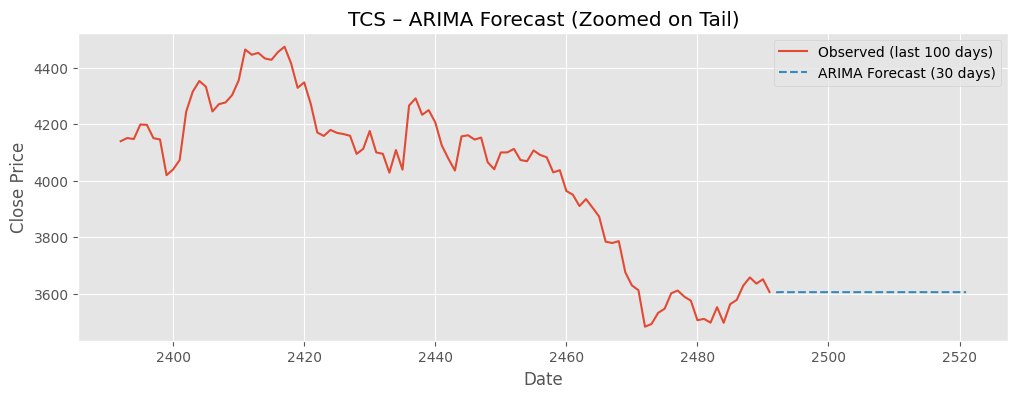

In [ ]:
arima_forecast = arima_model.forecast(steps=10)
print("\nNext 10-day ARIMA(1,1,1) forecast:")
print(arima_forecast)

steps = 30   # increase if you want a longer forecast
arima_forecast = arima_model.forecast(steps=steps)

# combine last part of history with forecast
history_tail = ts.tail(100)   # last 100 days of data

plt.figure(figsize=(12,4))
plt.plot(history_tail.index, history_tail.values, label="Observed (last 100 days)")
plt.plot(arima_forecast.index, arima_forecast.values,
         label=f"ARIMA Forecast ({steps} days)", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("TCS – ARIMA Forecast (Zoomed on Tail)")
plt.legend()
plt.grid(True)
plt.show()


=== SARIMA(1,1,1)(1,1,1,30) ===
                                     SARIMAX Results                                      
Dep. Variable:                        Close_Price   No. Observations:                 2492
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 30)   Log Likelihood              -13404.903
Date:                            Fri, 21 Nov 2025   AIC                          26819.806
Time:                                    11:40:46   BIC                          26848.848
Sample:                                         0   HQIC                         26830.358
                                           - 2492                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7027      0.474     -1.483      0.138      -1.631       0.226
ma

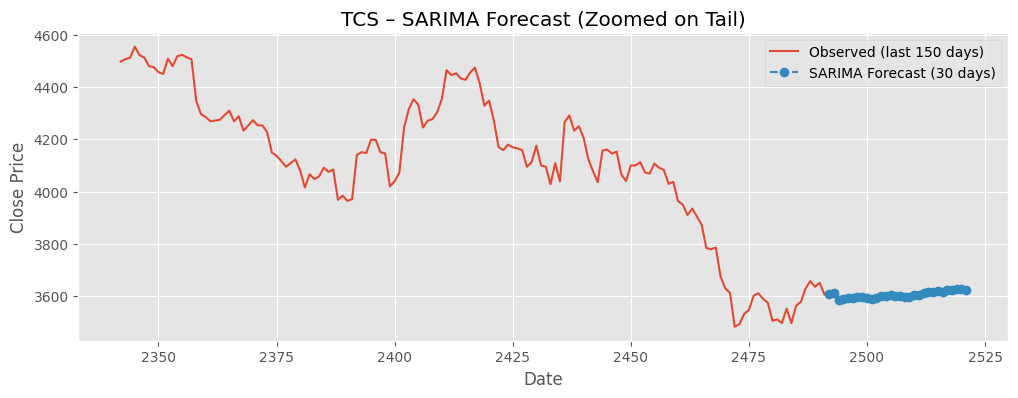

In [ ]:
sarima_model = SARIMAX(ts,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 30)
                      ).fit()
print("\n=== SARIMA(1,1,1)(1,1,1,30) ===")
print(sarima_model.summary())




steps_s = 30   # e.g. 60 days ahead
sarima_forecast = sarima_model.forecast(steps=steps_s)

history_tail = ts.tail(150)   # last 150 days

plt.figure(figsize=(12,4))
plt.plot(history_tail.index, history_tail.values, label="Observed (last 150 days)")
plt.plot(sarima_forecast.index, sarima_forecast.values,
         label=f"SARIMA Forecast ({steps_s} days)", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("TCS – SARIMA Forecast (Zoomed on Tail)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def run_all_models(series, name="Series"):
    print("\n===================================")
    print(f"📍 Running models for: {name}")
    print("===================================")

    # ---- ADF Test ----
    adf_test(series, name)

    # ---- ACF / PACF ----
    fig, ax = plt.subplots(1, 2, figsize=(14,4))
    plot_acf(series, lags=30, ax=ax[0])
    plot_pacf(series, lags=30, ax=ax[1])
    ax[0].set_title(f"ACF - {name}")
    ax[1].set_title(f"PACF - {name}")
    plt.show()

    # ---- AR Model ----
    ar_model = AutoReg(series, lags=2).fit()
    print("\n=== AR(2) ===")
    print(ar_model.summary())

    # ---- MA Model ----
    ma_model = ARIMA(series, order=(0,0,2)).fit()
    print("\n=== MA(2) ===")
    print(ma_model.summary())

    # ---- ARMA Model ----
    arma_model = ARIMA(series, order=(2,0,2)).fit()
    print("\n=== ARMA(2,2) ===")
    print(arma_model.summary())

    # ---- ARIMA (Returns do not need differencing) ----
    arima_model = ARIMA(series, order=(2,0,1)).fit()
    print("\n=== ARIMA(2,0,1) ===")
    print(arima_model.summary())

    # ---- SARIMA (Seasonal Period ~30 Trading Days) ----
    sarima_model = SARIMAX(series,
                           order=(2,0,1),
                           seasonal_order=(1,0,1,30)
                          ).fit()
    print("\n=== SARIMA(2,0,1)(1,0,1,30) ===")
    print(sarima_model.summary())

    # ---- Forecast & Plot ----
    steps = 60
    forecast = sarima_model.forecast(steps=steps)

    plt.figure(figsize=(12,4))
    plt.plot(series.tail(200), label=f"{name} (last 200 points)")
    plt.plot(forecast, label=f"SARIMA Forecast ({steps} steps)", linestyle="--")
    plt.title(f"Forecast for {name}")
    plt.grid(True)
    plt.legend()
    plt.show()

    return {
        "AR": ar_model,
        "MA": ma_model,
        "ARMA": arma_model,
        "ARIMA": arima_model,
        "SARIMA": sarima_model,
        "forecast": forecast
    }



📍 Running models for: Returns

ADF test for Returns
  ADF Statistic : -50.12670112279103
  p-value       : 0.0
  Critical Value 1%: -3.4329789374204935
  Critical Value 5%: -2.8627014485379787
  Critical Value 10%: -2.5673882843825098


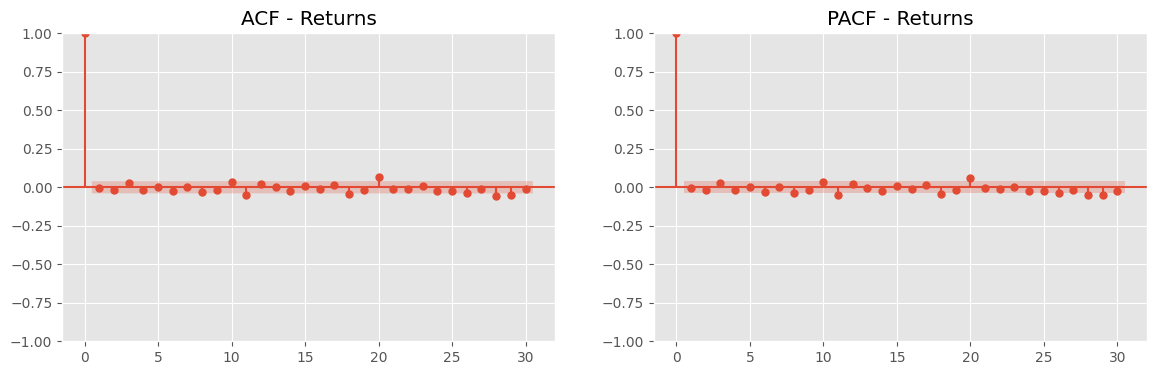


=== AR(2) ===
                            AutoReg Model Results                             
Dep. Variable:                Returns   No. Observations:                 2491
Model:                     AutoReg(2)   Log Likelihood                6477.390
Method:               Conditional MLE   S.D. of innovations              0.018
Date:                Fri, 21 Nov 2025   AIC                         -12946.779
Time:                        11:48:12   BIC                         -12923.501
Sample:                             2   HQIC                        -12938.326
                                 2491                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      0.921      0.357      -0.000       0.001
Returns.L1    -0.0052      0.020     -0.258      0.797      -0.044       0.034
Returns.L2    -0.0202      0.020     

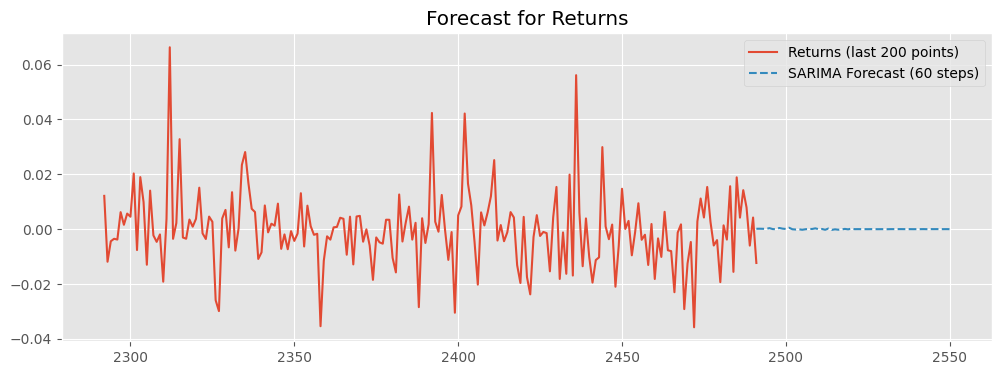

In [ ]:
results_returns = run_all_models(tcs["Returns"].dropna(), name="Returns")


📍 Running models for: Log_Returns

ADF test for Log_Returns
  ADF Statistic : -49.98561574444995
  p-value       : 0.0
  Critical Value 1%: -3.4329789374204935
  Critical Value 5%: -2.8627014485379787
  Critical Value 10%: -2.5673882843825098


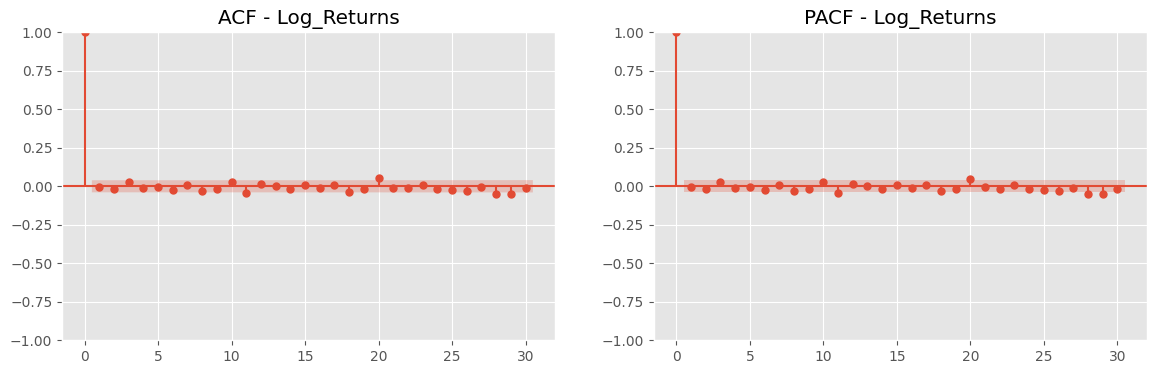


=== AR(2) ===
                            AutoReg Model Results                             
Dep. Variable:            Log_Returns   No. Observations:                 2491
Model:                     AutoReg(2)   Log Likelihood                6153.143
Method:               Conditional MLE   S.D. of innovations              0.020
Date:                Fri, 21 Nov 2025   AIC                         -12298.286
Time:                        11:48:27   BIC                         -12275.007
Sample:                             2   HQIC                        -12289.833
                                 2491                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0001      0.000      0.334      0.739      -0.001       0.001
Log_Returns.L1    -0.0023      0.020     -0.112      0.910      -0.042       0.037
Log_Returns.L2    -0.

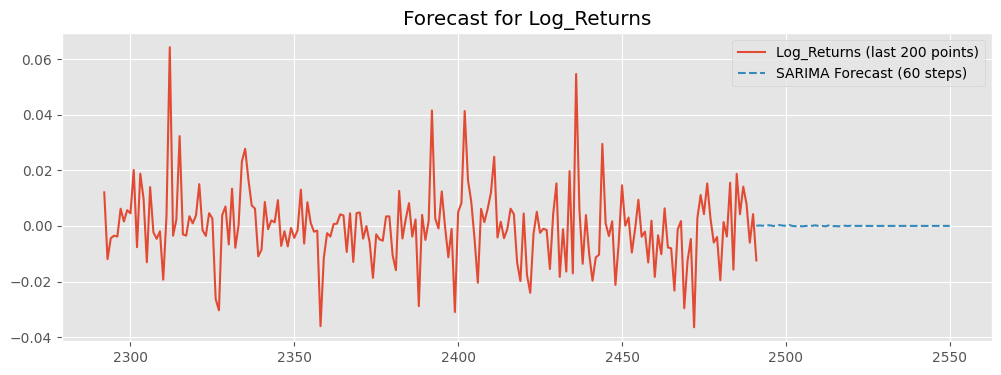

In [ ]:
results_log_returns = run_all_models(tcs["Log_Returns"].dropna(), name="Log_Returns")


Daily stock closing prices are typically difficult to forecast using ARIMA and SARIMA models because stock prices behave like a non-stationary random walk, meaning today’s price already reflects all available information and future prices are primarily driven by new, unpredictable market shocks rather than past values. When prices are differenced to achieve stationarity, the resulting return series often resembles white noise, showing negligible autocorrelation and no meaningful seasonal structure; therefore, AR and MA components collapse to zero, and SARIMA models produce flat forecasts equal to the last observed value. This indicates that ARIMA-family models are not well suited for predicting stock price levels, and modeling volatility (e.g., using GARCH) or incorporating external features and events through multivariate or machine learning models provides more meaningful predictive power.